# LeetCode #29: Divide Two Integers

https://leetcode.com/problems/divide-two-integers/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(1)$ |
| **Bit-Shift Exponential** ★ | $O(\log^2 n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Repeatedly subtract the divisor from the dividend, counting iterations until the remainder is smaller than the divisor. Each subtraction reduces the dividend by one divisor-unit, so the loop runs $|quotient|$ times — $O(n)$ where $n = |dividend / divisor|$, making it impractical for large inputs (e.g., $2^{31}-1$ divided by $1$).

### Optimal: Bit-Shift Exponential ★
At each outer iteration, left-shift the divisor until doubling it would exceed the remaining dividend; subtract that largest multiple and add its corresponding power-of-two to the quotient. Repeat on the remainder. Each outer step halves the remaining dividend, and each inner doubling loop runs at most $\log_2 n$ steps, giving $O(\log^2 n)$ overall with $O(1)$ space.

**Why this is better than Brute Force:** Instead of subtracting one divisor at a time, each outer iteration subtracts the largest possible power-of-two multiple of the divisor — exponentially reducing the remainder rather than linearly.

**Constraints:**
* $-2^{31} \leq$ dividend, divisor $\leq 2^{31}-1$
* divisor $\neq 0$
* Result must be clamped to $[-2^{31},\, 2^{31}-1]$

## Solutions

### C#

In [ ]:
public class Solution {
    public int Divide(int dividend, int divisor) {
        // Guard: the only case that overflows 32-bit on return
        if (dividend == int.MinValue && divisor == -1) return int.MaxValue;

        // Work in non-negative long to avoid int overflow during shifts
        bool negative = (dividend < 0) != (divisor < 0);
        long dvd = Math.Abs((long)dividend);
        long dvs = Math.Abs((long)divisor);
        int quotient = 0;

        // Outer loop: reduce remainder until it falls below the divisor
        while (dvd >= dvs) {
            long shifted = dvs;
            int multiple = 1;
            // Double the shifted divisor until the next doubling would overshoot
            while (dvd >= (shifted << 1)) {
                shifted <<= 1;
                multiple <<= 1;
            }
            // Subtract the largest fitting multiple and record its contribution
            dvd -= shifted;
            quotient += multiple;
        }

        return negative ? -quotient : quotient;
    }
}

### Python

In [ ]:
class Solution:
    def divide(self, dividend: int, divisor: int) -> int:
        INT_MAX = 2**31 - 1
        INT_MIN = -(2**31)

        # Guard: the only case that overflows 32-bit on return
        if dividend == INT_MIN and divisor == -1:
            return INT_MAX

        # Work with absolute values; track sign separately
        negative = (dividend < 0) != (divisor < 0)
        dvd = abs(dividend)
        dvs = abs(divisor)
        quotient = 0

        # Outer loop: reduce remainder until it falls below the divisor
        while dvd >= dvs:
            shifted = dvs
            multiple = 1
            # Double the shifted divisor until the next doubling would overshoot
            while dvd >= (shifted << 1):
                shifted <<= 1
                multiple <<= 1
            # Subtract the largest fitting multiple and record its contribution
            dvd -= shifted
            quotient += multiple

        return -quotient if negative else quotient


### Go

In [ ]:
func divide(dividend int, divisor int) int {
    const intMax = 1<<31 - 1
    const intMin = -(1 << 31)

    // Guard: the only case that overflows 32-bit on return
    if dividend == intMin && divisor == -1 {
        return intMax
    }

    // Work with absolute values; track sign separately
    negative := (dividend < 0) != (divisor < 0)
    dvd := abs64(int64(dividend))
    dvs := abs64(int64(divisor))
    quotient := 0

    // Outer loop: reduce remainder until it falls below the divisor
    for dvd >= dvs {
        shifted := dvs
        multiple := 1
        // Double the shifted divisor until the next doubling would overshoot
        for dvd >= shifted<<1 {
            shifted <<= 1
            multiple <<= 1
        }
        // Subtract the largest fitting multiple and record its contribution
        dvd -= shifted
        quotient += multiple
    }

    if negative {
        return -quotient
    }
    return quotient
}

func abs64(x int64) int64 {
    if x < 0 {
        return -x
    }
    return x
}

### Rust

In [ ]:
pub fn divide(dividend: i32, divisor: i32) -> i32 {
    // Guard: the only case that overflows 32-bit on return
    if dividend == i32::MIN && divisor == -1 {
        return i32::MAX;
    }

    // Work with absolute values as i64; track sign separately
    let negative = (dividend < 0) != (divisor < 0);
    let mut dvd = (dividend as i64).unsigned_abs() as i64;
    let dvs = (divisor as i64).unsigned_abs() as i64;
    let mut quotient: i64 = 0;

    // Outer loop: reduce remainder until it falls below the divisor
    while dvd >= dvs {
        let mut shifted = dvs;
        let mut multiple: i64 = 1;
        // Double the shifted divisor until the next doubling would overshoot
        while dvd >= shifted << 1 {
            shifted <<= 1;
            multiple <<= 1;
        }
        // Subtract the largest fitting multiple and record its contribution
        dvd -= shifted;
        quotient += multiple;
    }

    if negative { -(quotient as i32) } else { quotient as i32 }
}

## Example Scenarios

**1. Common Case**
**Input:** dividend = 10, divisor = 3
First doubling pass: $3 \to 6 \to 12 > 10$, so largest fit is $6 = 3 \cdot 2^1$; subtract to get remainder $4$, add $2$ to quotient. Second pass: $3 \leq 4$, subtract $3$, add $1$; remainder $1 < 3$, stop. Output: $3$.

**2. Slightly Complex — mixed signs**
**Input:** dividend = −22, divisor = 4
Signs differ so result is negative. Work on $|{-22}| = 22$, $|4| = 4$. First pass doubles to $4 \to 8 \to 16 \leq 22 < 32$; subtract $16$, add $4$. Second pass: $4 \leq 6$; subtract $4$, add $1$; remainder $2 < 4$, stop. Raw quotient $= 5$, so output: $-5$.

**3. Edge Case: Time Factor — divisor = 1**
**Input:** dividend = 2147483647, divisor = 1
Worst-case outer loop: the remainder halves after each subtraction only at the granularity of the current shift, requiring up to $\log_2(2^{31}) = 31$ outer iterations each with up to $31$ inner doubling steps — roughly $31^2 \approx 961$ operations. Output: $2147483647$.

**4. Edge Case: Space Factor — divisor equals dividend**
**Input:** dividend = −2147483648, divisor = −2147483648
Both negative → positive result. Absolute values are equal, so the first doubling immediately overshoots; one subtraction yields remainder $0$, quotient $= 1$. Only a constant number of scalar variables used. Output: $1$.

**5. Almost-Impossible but Plausible — overflow: INT\_MIN ÷ −1**
**Input:** dividend = −2147483648, divisor = −1
True mathematical result is $2^{31} = 2147483648$, which exceeds $2^{31}-1$. This is the sole overflow case; an early guard returns $\text{INT\_MAX} = 2147483647$ immediately without entering the shift loop. Output: $2147483647$.

## Infographic

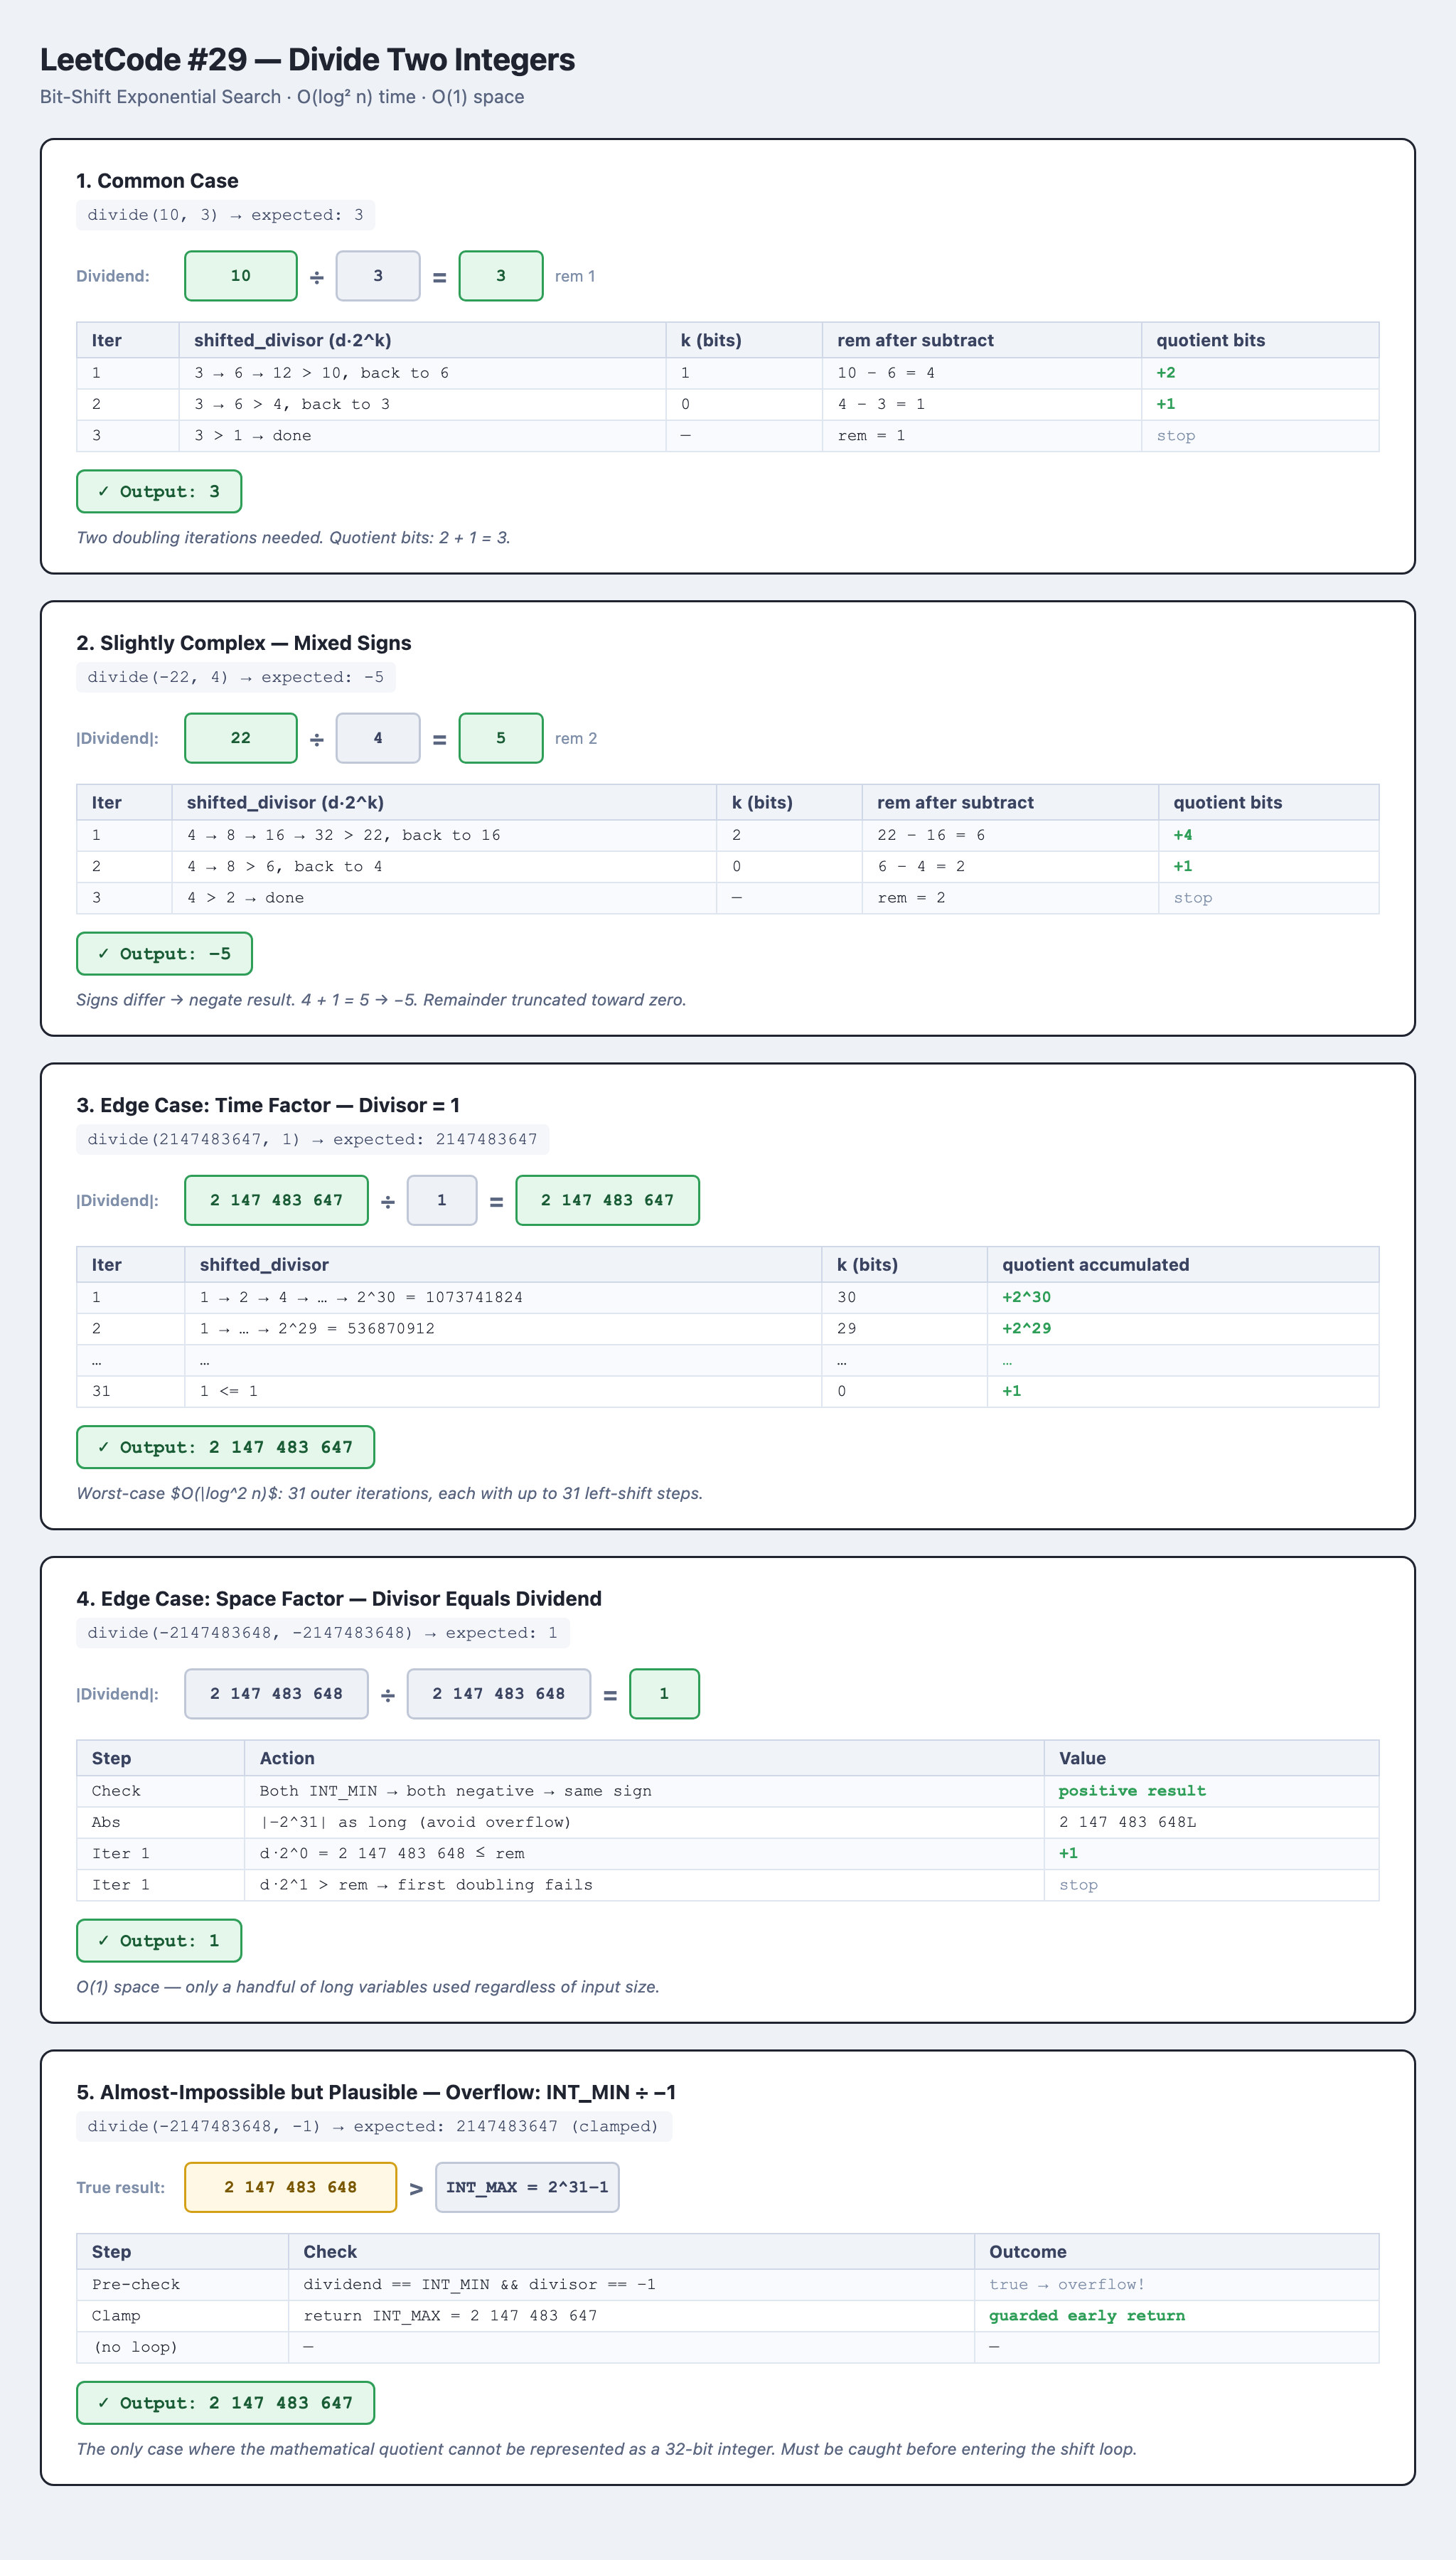